
RUNNING EXPERIMENT: Population Size = 10
gen    0 | best=23 | avg=18.90
gen  100 | best=24 | avg=21.10
gen  200 | best=26 | avg=23.30
gen  300 | best=23 | avg=21.90
gen  400 | best=23 | avg=20.80
gen  500 | best=24 | avg=22.60
gen  600 | best=26 | avg=23.80
gen  700 | best=27 | avg=24.10
gen  800 | best=25 | avg=22.60
gen  900 | best=22 | avg=19.50

[STOPPED] Max iterations reached. Best fitness achieved: 22/28

--- Generation Snapshots ---

Generation 0 | Chromosome: [0, 5, 6, 4, 1, 6, 2, 7] | Fitness: 23/28
8  . . . . . . . Q
7  . . Q . . Q . .
6  . Q . . . . . .
5  . . . Q . . . .
4  . . . . . . . .
3  . . . . . . Q .
2  . . . . Q . . .
1  Q . . . . . . .
   1 2 3 4 5 6 7 8

Generation 999 | Chromosome: [3, 7, 0, 0, 7, 2, 1, 6] | Fitness: 22/28
8  . Q . . Q . . .
7  . . . . . . . Q
6  . . . . . . . .
5  . . . . . . . .
4  Q . . . . . . .
3  . . . . . Q . .
2  . . . . . . Q .
1  . . Q Q . . . .
   1 2 3 4 5 6 7 8


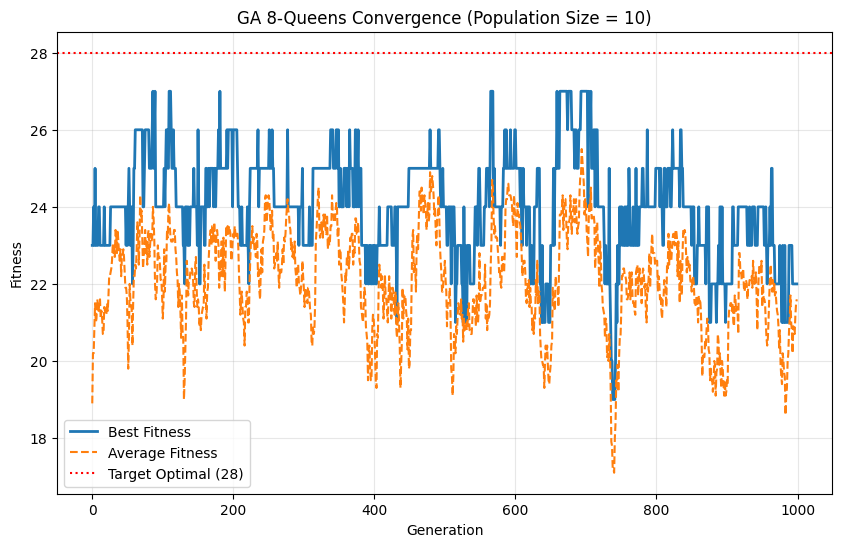


RUNNING EXPERIMENT: Population Size = 100
gen    0 | best=26 | avg=20.38
gen  100 | best=26 | avg=21.38
gen  200 | best=26 | avg=22.19

[SUCCESS] Solved at generation 211

--- Generation Snapshots ---

Generation 0 | Chromosome: [1, 3, 0, 2, 7, 1, 6, 0] | Fitness: 26/28
8  . . . . Q . . .
7  . . . . . . Q .
6  . . . . . . . .
5  . . . . . . . .
4  . Q . . . . . .
3  . . . Q . . . .
2  Q . . . . Q . .
1  . . Q . . . . Q
   1 2 3 4 5 6 7 8

Generation 211 | Chromosome: [3, 7, 0, 2, 5, 1, 6, 4] | Fitness: 28/28
8  . Q . . . . . .
7  . . . . . . Q .
6  . . . . Q . . .
5  . . . . . . . Q
4  Q . . . . . . .
3  . . . Q . . . .
2  . . . . . Q . .
1  . . Q . . . . .
   1 2 3 4 5 6 7 8


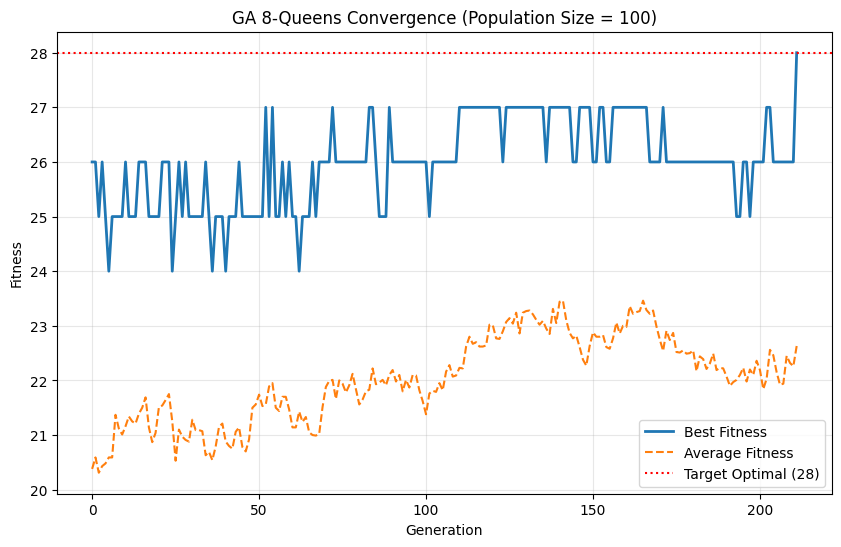


RUNNING EXPERIMENT: Population Size = 500
gen    0 | best=26 | avg=20.25
gen  100 | best=27 | avg=21.41

[SUCCESS] Solved at generation 180

--- Generation Snapshots ---

Generation 0 | Chromosome: [2, 5, 0, 4, 7, 5, 3, 6] | Fitness: 26/28
8  . . . . Q . . .
7  . . . . . . . Q
6  . Q . . . Q . .
5  . . . Q . . . .
4  . . . . . . Q .
3  Q . . . . . . .
2  . . . . . . . .
1  . . Q . . . . .
   1 2 3 4 5 6 7 8

Generation 180 | Chromosome: [5, 3, 6, 0, 7, 1, 4, 2] | Fitness: 28/28
8  . . . . Q . . .
7  . . Q . . . . .
6  Q . . . . . . .
5  . . . . . . Q .
4  . Q . . . . . .
3  . . . . . . . Q
2  . . . . . Q . .
1  . . . Q . . . .
   1 2 3 4 5 6 7 8


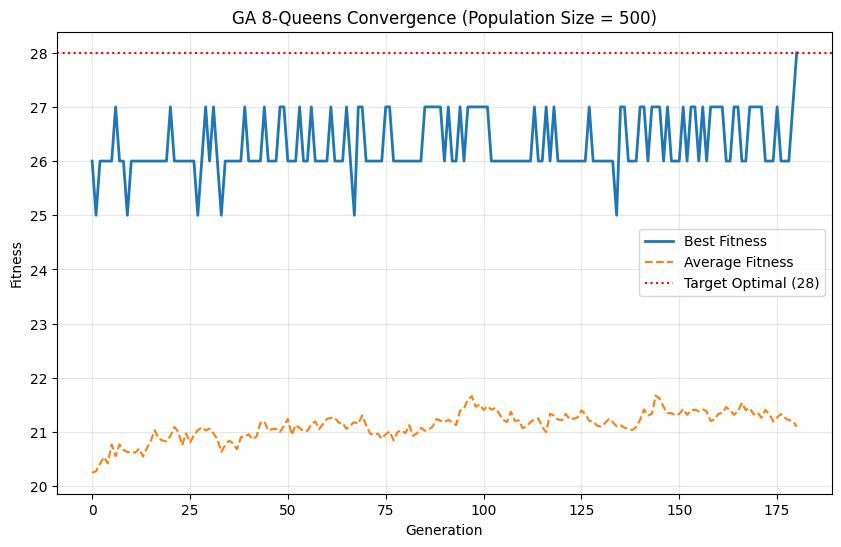


RUNNING EXPERIMENT: Population Size = 1000
gen    0 | best=26 | avg=20.16
gen  100 | best=26 | avg=20.90

[SUCCESS] Solved at generation 191

--- Generation Snapshots ---

Generation 0 | Chromosome: [4, 4, 7, 0, 6, 1, 1, 5] | Fitness: 26/28
8  . . Q . . . . .
7  . . . . Q . . .
6  . . . . . . . Q
5  Q Q . . . . . .
4  . . . . . . . .
3  . . . . . . . .
2  . . . . . Q Q .
1  . . . Q . . . .
   1 2 3 4 5 6 7 8

Generation 191 | Chromosome: [2, 5, 7, 0, 4, 6, 1, 3] | Fitness: 28/28
8  . . Q . . . . .
7  . . . . . Q . .
6  . Q . . . . . .
5  . . . . Q . . .
4  . . . . . . . Q
3  Q . . . . . . .
2  . . . . . . Q .
1  . . . Q . . . .
   1 2 3 4 5 6 7 8


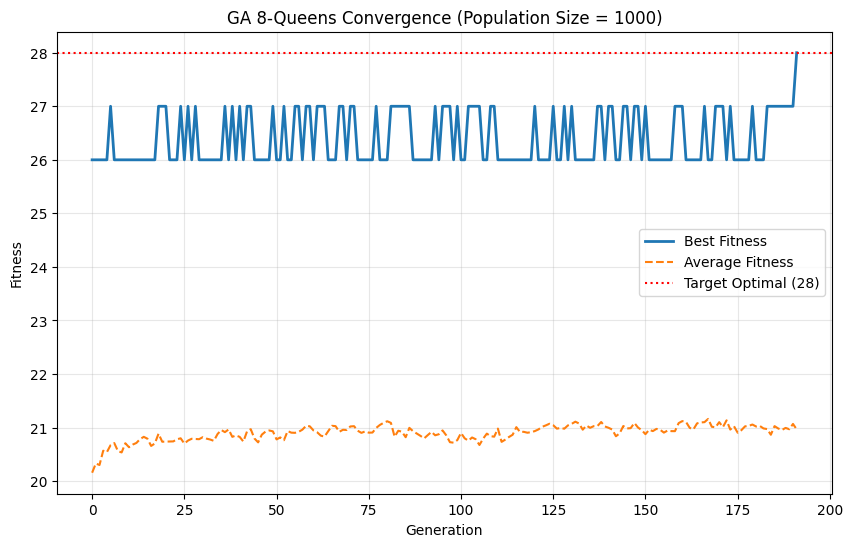

In [20]:
import random
import matplotlib.pyplot as plt

num_queens = 8
max_fitness = num_queens * (num_queens - 1) // 2


def random_chromosome():
    return [random.randint(0, num_queens - 1) for _ in range(num_queens)]


def fitness(chrom):
    attacking = 0
    for i in range(num_queens):
        for j in range(i + 1, num_queens):
            same_row = chrom[i] == chrom[j]
            same_diag = abs(chrom[i] - chrom[j]) == abs(i - j)
            if same_row or same_diag:
                attacking += 1
    return max_fitness - attacking


def roulette_select(pop, fitnesses):
    return random.choices(pop, weights=fitnesses, k=1)[0]


def crossover(p1, p2):
    cut = random.randint(1, num_queens - 1)
    child1 = p1[:cut] + p2[cut:]
    child2 = p2[:cut] + p1[cut:]
    return child1, child2


def mutate(chrom, mutation_pct):
    if random.random() < mutation_pct:
        i = random.randint(0, num_queens - 1)
        chrom[i] = random.randint(0, num_queens - 1)
    return chrom


def print_board(chrom):
    for row in range(num_queens - 1, -1, -1):
        cells = " ".join("Q" if chrom[c] == row else "." for c in range(num_queens))
        print(f"{row + 1}  {cells}")
    print("   " + " ".join(str(c + 1) for c in range(num_queens)))


def run_ga(pop_size=100, num_iterations=1000, mutation_pct=0.2, verbose=True):
    pop = [random_chromosome() for _ in range(pop_size)]
    fits = [fitness(c) for c in pop]

    best_history = []
    avg_history = []
    samples = {}

    best_idx = max(range(pop_size), key=lambda i: fits[i])
    samples[0] = (pop[best_idx][:], fits[best_idx])
    best_so_far = fits[best_idx]

    solved_at = None

    for gen in range(num_iterations):
        best_history.append(max(fits))
        avg_history.append(sum(fits) / pop_size)

        if verbose and gen % 100 == 0:
            print(f"gen {gen:4d} | best={best_history[-1]} | avg={avg_history[-1]:.2f}")

        current_best = max(fits)
        if current_best > best_so_far:
            best_so_far = current_best
            best_idx = max(range(pop_size), key=lambda i: fits[i])
            samples[gen] = (pop[best_idx][:], current_best)

        if current_best == max_fitness:
            solved_at = gen
            break

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = roulette_select(pop, fits)
            p2 = roulette_select(pop, fits)
            c1, c2 = crossover(p1, p2)
            mutate(c1, mutation_pct)
            mutate(c2, mutation_pct)
            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)

        pop = new_pop
        fits = [fitness(c) for c in pop]

    best_idx = max(range(len(pop)), key=lambda i: fits[i])
    final_gen = len(best_history) - 1
    samples[final_gen] = (pop[best_idx][:], fits[best_idx])

    return {
        "best_history": best_history,
        "avg_history": avg_history,
        "samples": samples,
        "solved_at": solved_at,
        "final_best": (pop[best_idx], fits[best_idx]),
    }


def plot_history(history, pop_size):
    plt.figure(figsize=(10, 6))
    plt.plot(history["best_history"], label="Best Fitness", linewidth=2)
    plt.plot(history["avg_history"], label="Average Fitness", linestyle="--")
    plt.axhline(y=max_fitness, color="red", linestyle=":", label=f"Target Optimal ({max_fitness})")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(f"GA 8-Queens Convergence (Population Size = {pop_size})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.close()


def main():
    population_sizes = [10, 100, 500, 1000]
    num_iterations = 1000
    mutation_pct = 0.2

    for pop_size in population_sizes:
        print("\n" + "=" * 60)
        print(f"RUNNING EXPERIMENT: Population Size = {pop_size}")
        print("=" * 60)

        history = run_ga(pop_size=pop_size, num_iterations=num_iterations, mutation_pct=mutation_pct)

        if history["solved_at"] is not None:
            print(f"\n[SUCCESS] Solved at generation {history['solved_at']}")
        else:
            chrom, fit = history["final_best"]
            print(f"\n[STOPPED] Max iterations reached. Best fitness achieved: {fit}/{max_fitness}")

        print("\n--- Generation Snapshots ---")
        first_gen = min(history["samples"].keys())
        last_gen = max(history["samples"].keys())

        for gen in [first_gen, last_gen]:
            chrom, fit = history["samples"][gen]
            print(f"\nGeneration {gen} | Chromosome: {chrom} | Fitness: {fit}/{max_fitness}")
            print_board(chrom)

        plot_history(history, pop_size)


if __name__ == "__main__":
    main()